In [13]:
# ============================================================
# NOTEBOOK 3 — Explainability avec SHAP
# Models : Random Forest + Logistic Regression
# Dataset : Breast Cancer
# ============================================================

import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

shap.initjs()

1. Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)


In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# explainer_rf = shap.TreeExplainer(rf)
# shap_values_rf = explainer_rf.shap_values(X_test)


RandomForestClassifier(n_estimators=200, random_state=42)

3. SHAP summary plot (RF)

In [4]:
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test)
# explainer_rf = shap.TreeExplainer(rf)
# shap_values = explainer_rf(X_test)


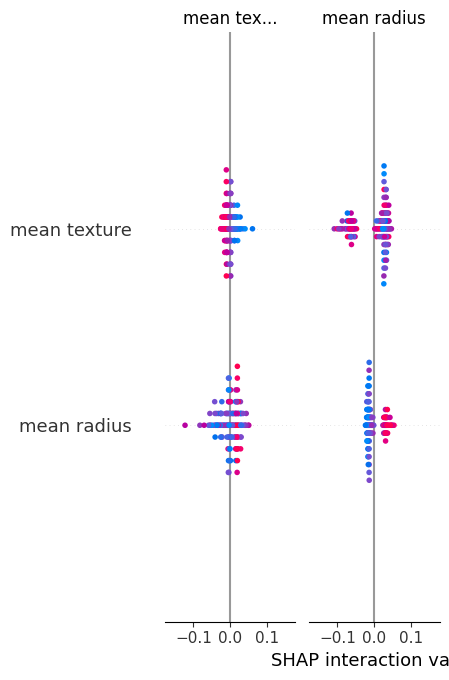

In [5]:
shap.summary_plot(shap_values_rf[:], X_test, plot_type="dot", show=True)


4. Logistic Regression + LinearExplainer

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_scaled, y_train)

explainer_lr = shap.LinearExplainer(logreg, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)


5. SHAP summary plot (LogReg)

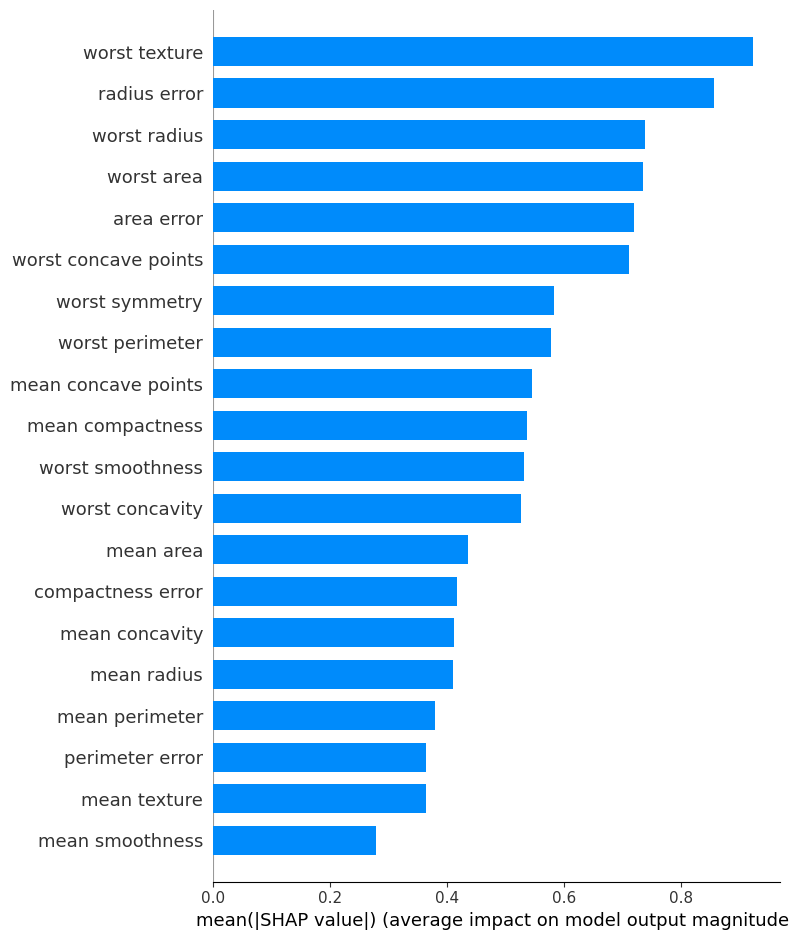

In [7]:
shap.summary_plot(shap_values_lr, X_test, plot_type="bar")


1️⃣ Compare SHAP RF vs SHAP Logistic :
      → Quelles variables dominent ?

2️⃣ Visualise un force_plot pour 5 individus.

3️⃣ Définis une pipeline :
        scaler + PCA + logistic
      → Analyse SHAP

4️⃣ Interprète la feature 'mean radius' :
      → Comment influence-t-elle le modèle ?

1. **Compare SHAP for Random Forest vs SHAP for Logistic Regression**  
   → Which features dominate?

2. **Visualize a `force_plot` for 5 individual samples.**

3. **Define a pipeline:**  

4. **Interpret the feature `mean radius`:**  
→ How does it influence the model?

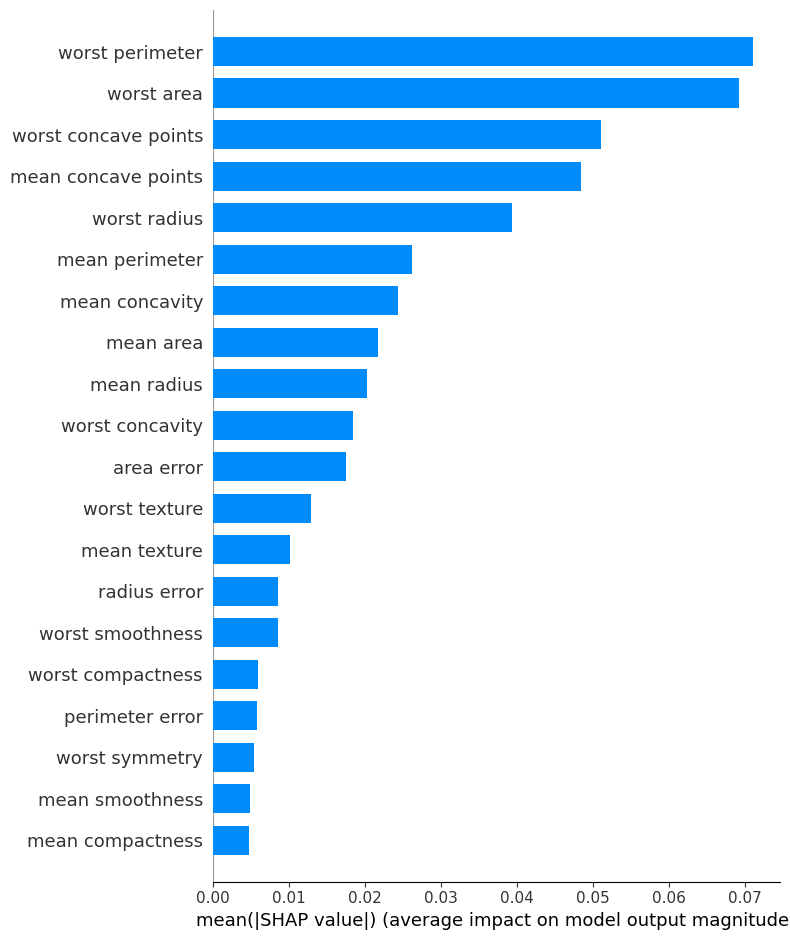

In [10]:
# SHAP pour Random Forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# SHAP pour Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression().fit(X_train_scaled, y_train)
explainer_log = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values_log = explainer_log.shap_values(X_test_scaled)

# Visualisation Summary Plot
if isinstance(shap_values_rf, list):
    values_to_plot = shap_values_rf[1]
else:
    values_to_plot = shap_values_rf[:, :, 1] if len(shap_values_rf.shape) == 3 else shap_values_rf

shap.summary_plot(values_to_plot, X_test, plot_type="bar")

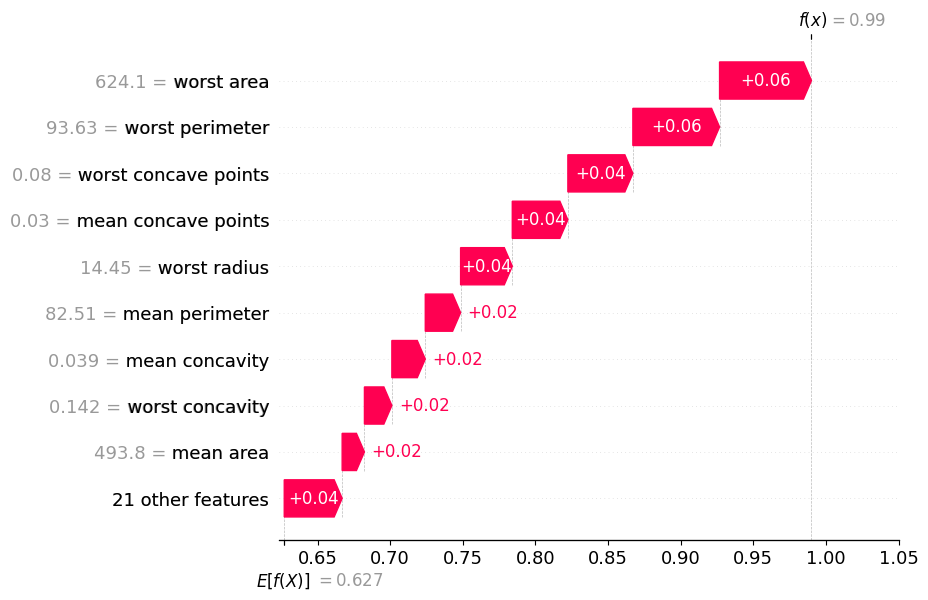

In [16]:
if isinstance(shap_values_rf, list):
    chosen_values = shap_values_rf[1][:5, :]
    base_value = explainer_rf.expected_value[1]
else:
    chosen_values = shap_values_rf[:5, :, 1] if len(shap_values_rf.shape) == 3 else shap_values_rf[:5, :]
    base_value = explainer_rf.expected_value[1]

# Affichage du force_plot
shap.plots.waterfall(explainer_rf(X_test)[0][:, 1])

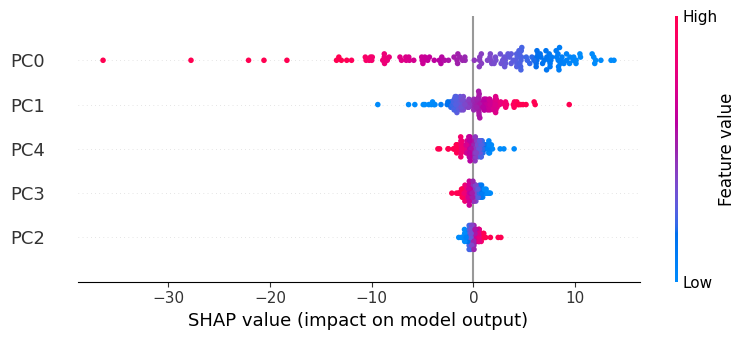

In [17]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('model', LogisticRegression())
])
pipeline.fit(X_train, y_train)

X_test_pca = pipeline.named_steps['pca'].transform(pipeline.named_steps['scaler'].transform(X_test))
explainer_pca = shap.LinearExplainer(pipeline.named_steps['model'], X_test_pca)
shap_values_pca = explainer_pca.shap_values(X_test_pca)

shap.summary_plot(shap_values_pca, X_test_pca, feature_names=[f"PC{i}" for i in range(5)])